In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
aa = pd.read_csv('2026-05-04_academy_awards_genre.csv')

In [3]:
aa.groupby(['Year','genre']).size().unstack(fill_value=0)

genre,Action,Adventure,Biography,Body Horror,Comedy,Coming-of-Age,Crime,Dark Comedy,Dark Romance,Drama,...,Romantic Comedy,Satire,Sci-Fi,Showbiz Drama,Sport,Superhero,Thriller,Tragedy,War,Western
Year,,,,,,,,,,,,,,,,,,,,,
2016,0,1,6,0,5,4,2,1,0,16,...,1,0,2,1,0,0,3,4,1,1
2017,2,1,5,1,5,2,3,3,2,15,...,1,1,2,0,1,1,4,1,4,0
2018,1,1,6,0,6,0,2,3,0,14,...,0,1,1,3,0,1,1,2,0,2
2019,3,0,6,0,5,3,3,2,0,15,...,0,2,0,1,1,0,3,2,2,0
2020,0,0,3,0,3,0,3,1,0,14,...,0,1,0,1,0,0,2,3,0,0
2021,1,1,6,0,4,5,2,1,0,18,...,2,1,2,3,1,0,2,2,0,1
2022,3,2,2,0,4,2,1,3,0,14,...,0,2,2,3,0,0,1,5,1,0
2023,0,1,4,0,5,1,2,3,0,12,...,0,2,1,0,1,0,0,1,1,1
2024,1,1,2,1,2,1,1,2,0,13,...,0,0,2,2,0,0,4,3,0,0


In [4]:
aa_counts = aa.groupby(['Year','genre']).size().unstack(fill_value=0)

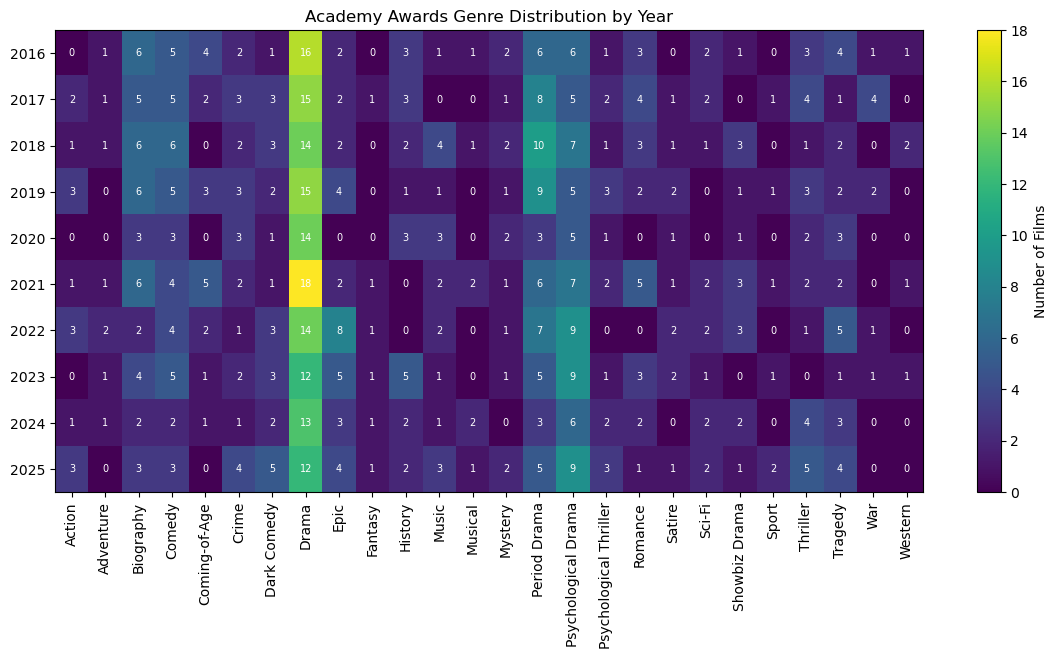

In [5]:
aa_filtered = aa_counts.loc[
    :, aa_counts.sum() >=5
    ]
fig, ax = plt.subplots(figsize = (14,6))
heatmap = ax.imshow(aa_filtered, aspect='auto')

ax.set_xticks(range(len(aa_filtered.columns)))
ax.set_yticks(range(len(aa_filtered.index)))
ax.set_xticklabels(aa_filtered.columns, rotation=90)
ax.set_yticklabels(aa_filtered.index)

for i, year in enumerate(aa_filtered.index):
    for j, genre in enumerate(aa_filtered.columns):
        ax.text(j, i, aa_filtered.loc[year, genre],
                ha="center", va="center", fontsize=7, color='white')

ax.set_title('Academy Awards Genre Distribution by Year')
plt.colorbar(heatmap, ax=ax, label= 'Number of Films')
fig.savefig('oscarsheatmap.jpg')

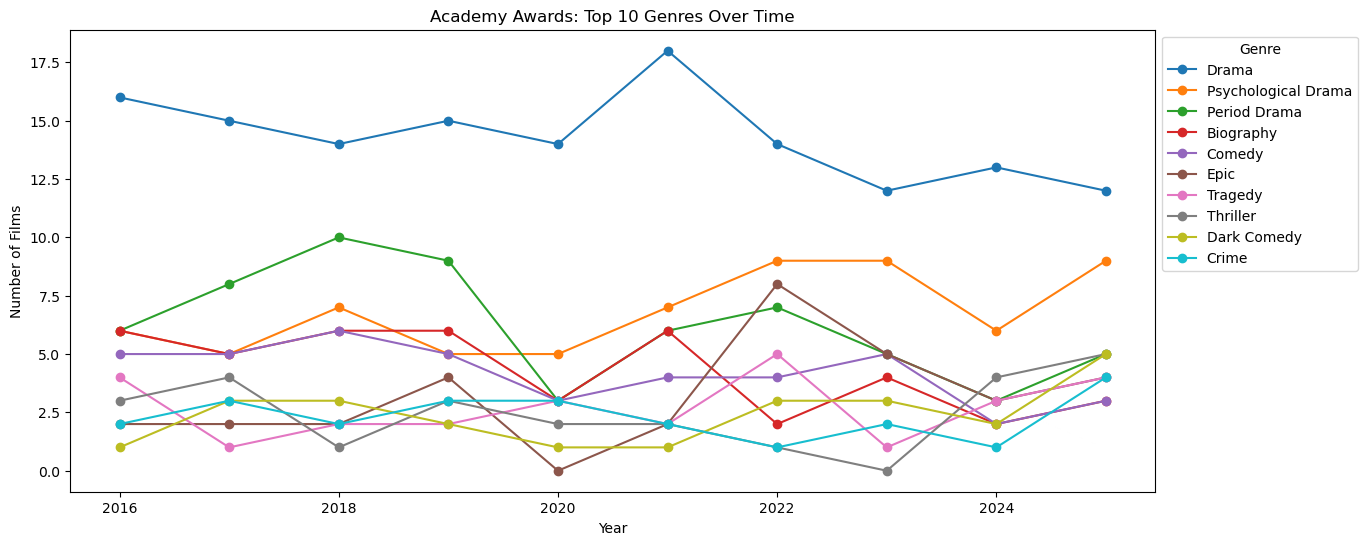

In [6]:
top_genres = aa_filtered.sum().nlargest(10).index
fig, ax = plt.subplots(figsize=(14,6))

for i in top_genres:
    ax.plot(
        aa_filtered.index,
        aa_filtered[i],
        marker='o',
        label=i)
ax.set_title('Academy Awards: Top 10 Genres Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Films')
ax.legend(title='Genre', bbox_to_anchor=(1,1), loc='upper left')
fig.savefig('oscarslinegraph.jpg')

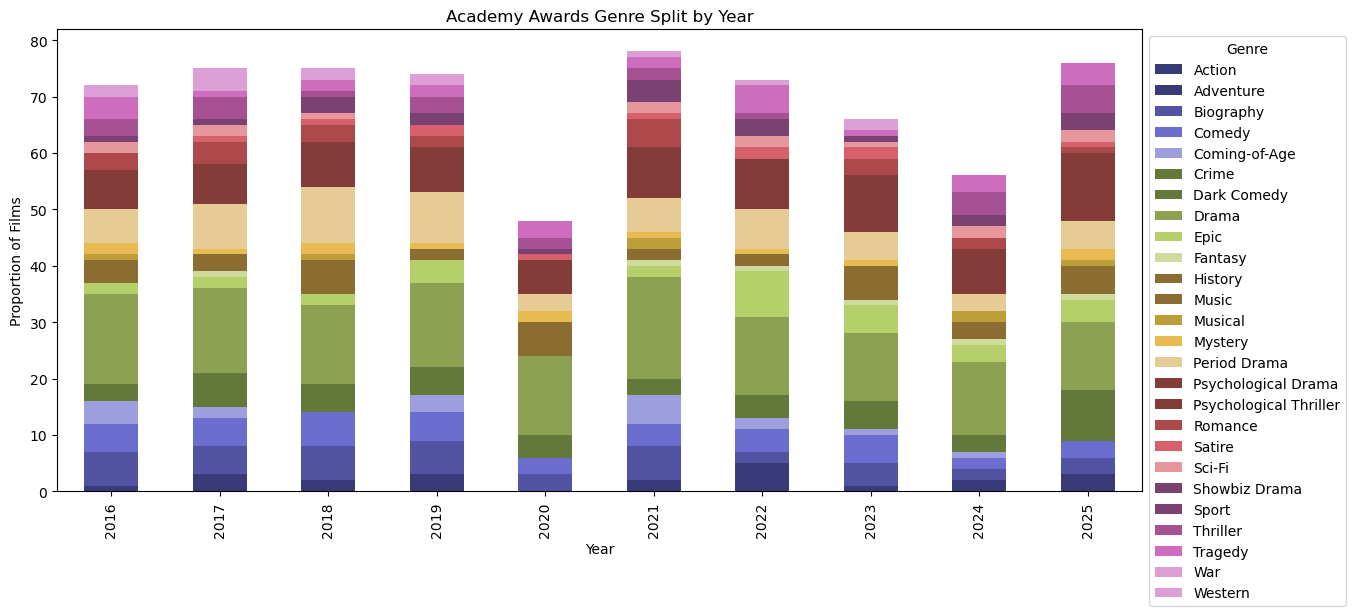

In [7]:
ax = aa_filtered.plot(kind='bar', figsize=(14,6),stacked=True,colormap='tab20b')
ax.set_title('Academy Awards Genre Split by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Films')
ax.legend(title='Genre',loc='upper left', bbox_to_anchor=(1,1))
fig.savefig('oscarsstackedbar.jpg')

In [8]:
aa_filtered = aa_filtered.sort_index()
percent_changes = {}
for col in aa_filtered:
    firstval = aa_filtered[col].iloc[0]
    lastval = aa_filtered[col].iloc[-1]
    if firstval == 0:
        percent_changes[col] = None
    else:
        percent_changes[col] = ((lastval - firstval)/firstval) *100  

In [9]:
percent = pd.Series(percent_changes)

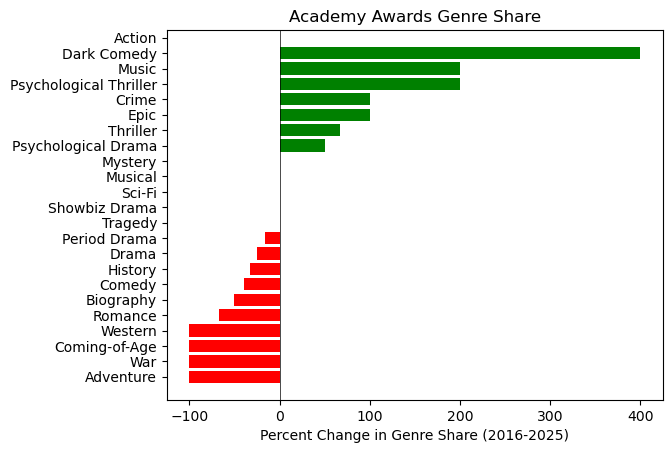

In [10]:
percent = percent.sort_values(ascending=True)

fig, ax = plt.subplots()
colors = ['green' if val >=0 else 'red' for val in percent.values]
bars = ax.barh(percent.index, percent.values, color=colors)
for bar, val in zip(bars, percent.values):
    sign = '+' if val >=0 else '-'
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Academy Awards Genre Share')
ax.set_xlabel('Percent Change in Genre Share (2016-2025)')
fig.savefig('oscarspercentchange.jpg')